# Deo II - Treniranje i evaluacija modela

## Moduli

In [1]:
import pandas as pd
import ast
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, accuracy_score, roc_auc_score, roc_curve
import numpy as np
import json

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

## Seed-ovi

In [2]:
RANDOM_STATE = 7
NP_RANDOM_STATE = 8
np.random.seed(NP_RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

torch.use_deterministic_algorithms(True)

## Pretprocesiranje skupa podataka

In [3]:
data = pd.read_csv('data/protein_data.csv')

In [4]:
data.head()

,accession,sequence,labels
0,P03265,MASREEEQRETTPERGRGAARRPPTMEDVSSPSPSPPPPRAPPKKR...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
1,P49913,MKTQRDGHSLGRWSLVLLLLGLVMPLAIIAQVLSYKEAVLRAIDGI...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
2,P03045,MDAQTRRRERRAEKQAQWKAANPLLVGVSAKPVNRPILSLNRKPKS...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,P00004,MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPG...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,P27695,MPKRGKKGAVAEDGDELRTEPEAKKSKTAAKKNDKEAAGEGPALYE...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [5]:
data.dtypes

accession    str
sequence     str
labels       str
dtype: object

In [6]:
data['labels'] = data['labels'].apply(ast.literal_eval)
#data.dtypes

Obe neuronske mreže koje treniramo će na početku sadržati `Embedding` sloj. Za to nam je potrebna fiksna dužina sekvence, pa analiziramo šta da postavimo za tu dužinu.

In [7]:
print("Max length: ", data['sequence'].str.len().max())
print("Average length: ", data['sequence'].str.len().mean())

Max length:  34350
Average length:  584.8510638297872


Vidimo da su neki stringovi vrlo dugacki, ali većina je zapravo relativno mala.

In [8]:
data['sequence_length'] = data['sequence'].str.len()
print("Number of proteins having length over 5000: ", data[data['sequence_length'] >= 5000].shape[0])
print("Number of proteins having length over 2000: ", data[data['sequence_length'] >= 2000].shape[0])
print("Number of proteins having length over 1000: ", data[data['sequence_length'] >= 1000].shape[0])
print("Number of proteins having length over 500: ", data[data['sequence_length'] >= 500].shape[0])
data[data['sequence_length'] >= 5000]

Number of proteins having length over 5000:  5
Number of proteins having length over 2000:  109
Number of proteins having length over 1000:  434
Number of proteins having length over 500:  1340


,accession,sequence,labels,sequence_length
52,Q8WZ42,MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",34350
1124,O14686,MDSQKLAGEDKDSEPAADGPAASEDPSATESDLPNPHVGEVSVLSS...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -...",5537
1948,P0C6X7,MESLVLGVNEKTHVQLSLPVLQVRDVLVRGFGDSVEEALSEAREHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",7073
1949,P0DTD1,MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",7096
3305,P11716,MGDGGEGEDEVQFLRTDDEVVLQCSATVLKEQLKLCLAAEGFGNRL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",5037


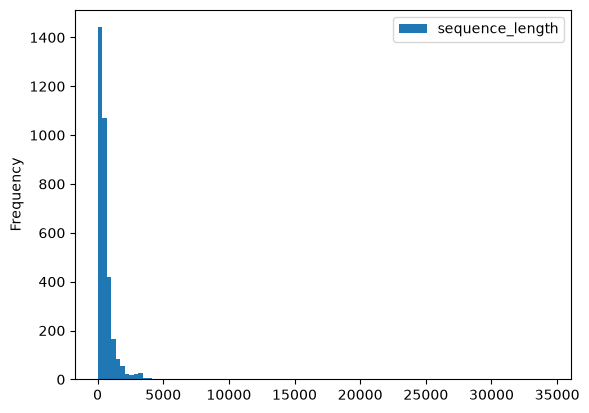

In [9]:
data.plot.hist(bins=100)
plt.show()

Nemamo mnogo proteina dužine veće od $1000$. Nema smisla vršiti padding do maksimalne dužine, pošto će većina instanci imati padding barem $30$ puta duži od njihove prave dužine. Ovaj problem mogli bismo da rešimo izbacivanjem velikih instanci iz skupa podataka, ali mi zaista želimo da smo u mogućnosti da analiziramo i velike proteine. Srećom, struktura naših modela nam omogućava da ovo jednostavno rešimo. Naime, jedan dugačak protein možemo deliti na više manjih, nad kojima model može vršiti predviđanja. Jedini problem koji ovde nastaje je što model gubi na izražajnosti kad su u pitanju dugački proteini, jer se smanjuje kontekst.

In [10]:
MAX_PROTEIN_LENGTH = 1000

RESIDUE_LIST  = list("ACDEFGHIKLMNPQRSTVWY")
VOCAB_SIZE = 22

def get_residue_position(c):
    for j in range(len(RESIDUE_LIST)):
        if c == RESIDUE_LIST[j]:
            # ostavljamo 0 za padding
            return j + 1
    # nestandardne aminokiseline dobijaju zajednicku vrednost
    return len(RESIDUE_LIST) + 1

def tokenize_sequences(sequences):
    result = []
    for sequence in sequences:
        tokenized_seq = []
        for c in sequence:
            tokenized_seq.append(get_residue_position(c.upper()))
        result.append(tokenized_seq)
    return result
    
tokenized_sequences = tokenize_sequences(data['sequence'])
#print(len(tokenized_sequences))
#print(tokenized_sequences[:5])

In [11]:
def split_and_pad(sequence_list, label_list):
    """
    Imamo dva zadatka:
    1) Podeliti predugacke proteine
    2) Pad-ovati prekratke proteine
    """
    
    seq_res = []
    lab_res = []
    
    cnt_new_splits = 0
    
    for i in range(len(sequence_list)):
        sequence = sequence_list[i]
        labels = label_list[i]
        
        # deljenje
        for j in range(len(sequence)):
            l = j*MAX_PROTEIN_LENGTH
            r = j*MAX_PROTEIN_LENGTH + MAX_PROTEIN_LENGTH
            
            if l >= len(sequence):
                break
            
            if j >= 1:
                cnt_new_splits += 1
            
            r = min(r, len(sequence))
            
            seq_split = sequence[l:r]
            lab_split = labels[l:r]
            
            start_len = len(seq_split)
            
            # padding
            for k in range(start_len, MAX_PROTEIN_LENGTH):
                # mozemo kao label dati istu "neutvrdjenu vrednost"
                # svakako to ne racunamo u funkciji greske
                seq_split.append(0)
                lab_split.append(-5)
            
            seq_res.append(seq_split)
            lab_res.append(lab_split)
            
    print("Generated ", cnt_new_splits, " new splits")
    
    return seq_res, lab_res
    
    
seq_train_val, seq_test, labels_train_val, labels_test = train_test_split(tokenized_sequences, data['labels'].tolist(), random_state = RANDOM_STATE, test_size = 0.2)
seq_train, seq_val, labels_train, labels_val = train_test_split(seq_train_val, labels_train_val, random_state = RANDOM_STATE, test_size = 0.2)

seq_train, labels_train = split_and_pad(seq_train, labels_train)
seq_val, labels_val = split_and_pad(seq_val, labels_val)
seq_test, labels_test = split_and_pad(seq_test, labels_test)

seq_train = np.array(seq_train)
labels_train = np.array(labels_train)
seq_val = np.array(seq_val)
labels_val = np.array(labels_val)
seq_test = np.array(seq_test)
labels_test = np.array(labels_test)

Generated  400  new splits
Generated  93  new splits
Generated  146  new splits


In [12]:
BATCH_SIZE = 64

train_loader = DataLoader(list(zip(seq_train, labels_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(list(zip(seq_val, labels_val)), batch_size=BATCH_SIZE)
test_loader = DataLoader(list(zip(seq_test, labels_test)), batch_size=BATCH_SIZE)

## Funkcije

In [13]:
def calculate_metrics(y_target, y_predicted):
    sensitivity = recall_score(y_target, y_predicted)
    specificity = recall_score(y_target, y_predicted, pos_label = 0)
    accuracy = accuracy_score(y_target, y_predicted)
    
    return {'sensitivity' : sensitivity, 'specificity' : specificity, 'accuracy' : accuracy}

In [14]:
from tqdm import tqdm

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, optimizer, n_epochs, train_loader, val_loader, threshold = 0.5):

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_steps': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_steps': []
    }

    device = get_device()
    
    training_step = 0
    
    best_valid_loss = float('inf')
    eps = 1e-5
    steps_since_improvement = 0
    early_stopping_patience = 5
    
    for epoch in tqdm(range(n_epochs)):

        # Training phase
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            batch_size = labels.size(0)
            labels = labels.to(torch.float32)

            raw_predictions = model(inputs).squeeze()
            probs = torch.sigmoid(raw_predictions) 
            
            mask = (labels > -1)
            
            loss = nn.BCEWithLogitsLoss()(raw_predictions[mask], labels[mask].float())
            accuracy = ((probs[mask] > threshold) == labels[mask]).float().mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(accuracy.item())
            metrics['train_steps'].append(training_step)
            training_step += 1

        # Validation phase
        model.eval()
        valid_loss = 0
        valid_accuracy = 0
        valid_samples = 0
        
        y_target = []
        y_predicted = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                batch_size = labels.size(0)
                labels = labels.to(torch.float32)

                raw_predictions = model(inputs).squeeze()
                probs = torch.sigmoid(raw_predictions)
                
                mask = (labels > -1)
            
                loss = nn.BCEWithLogitsLoss(reduction='sum')(raw_predictions[mask], labels[mask])
                
                correct = ((probs[mask] > threshold) == labels[mask]).float().sum()
                
                y_target.extend((labels[mask]).cpu().numpy())
                y_predicted.extend((probs[mask] > threshold).cpu().numpy())
                
                valid_loss += loss.item()
                valid_accuracy += correct.item()
                valid_samples += mask.sum()
                
        valid_loss /= valid_samples.item()
        valid_accuracy /= valid_samples.item()
        
        adv_metrics = calculate_metrics(y_target, y_predicted)
        
        metrics['val_loss'].append(valid_loss)
        metrics['val_accuracy'].append(adv_metrics['accuracy'])
        metrics['val_steps'].append(training_step)
        
        #print('Epoch', epoch, ':', 'Loss', valid_loss, 'Accuracy', adv_metrics['accuracy'], 'Sensitivity', adv_metrics['sensitivity'], 'Specificity', adv_metrics['specificity'])
        
        if best_valid_loss > valid_loss + eps:
            best_valid_loss = valid_loss
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
            if steps_since_improvement == early_stopping_patience:
                print("\nEARLY STOPPING\n")
                break
        
    
    return metrics

In [15]:
def plot_metrics(metrics):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss')
    plt.plot(metrics['val_steps'], metrics['val_loss'], label='Validation Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy')
    plt.plot(metrics['val_steps'], metrics['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, evaluation_loader, threshold):
    y = []
    y_predicted = []
    y_probs = []
    
    device = get_device()
    
    for inputs, labels in evaluation_loader:
        mask = (labels > -1)
        
        y.extend(labels[mask].squeeze().tolist())
        
        inputs, labels = inputs.to(device), labels.to(device)
        
        raw_preds = model(inputs).squeeze()
        probs = torch.sigmoid(raw_preds)
        preds = (probs > threshold)
        
        y_probs.extend(probs[mask].squeeze().tolist())
        y_predicted.extend(preds[mask].squeeze().tolist())

    adv_metrics = calculate_metrics(y, y_predicted)
    
    adv_metrics['confusion_matrix'] = confusion_matrix(y, y_predicted)
    adv_metrics['classification_report'] = classification_report(y, y_predicted)
    adv_metrics['roc_auc_score'] = roc_auc_score(y, y_probs)
    adv_metrics['probs'] = y_probs
    adv_metrics['labels'] = y
    
    return adv_metrics

## 1D Konvolutivna neuronska mreža

In [17]:
class ConvModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_layers):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        kernel = 5
        channels = 64
        in_channels = embedding_dim
        dropout = 0.3
        
        conv_layers = []
        
        for i in range(n_layers):
            # velika dilatacija kako bismo pokupili sirok kontekst
            dilation = (2 ** i)
            # padding odgovarajuce velicine, kako bismo ocuvali duzinu niza
            pad = dilation * (kernel - 1) // 2
            conv_layers.append(nn.Conv1d(in_channels, channels, kernel_size=kernel, padding = pad, dilation=dilation))
            
            # trebaju nam svi elementi niza, ne mozemo pool-ovati
            conv_layers.append(nn.BatchNorm1d(channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout))
            
            in_channels = channels
            
        self.full_conv = nn.Sequential(*conv_layers)
        
        self.conv_final = nn.Conv1d(channels, 1, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.full_conv(x)
        x = self.conv_final(x)
        
        return x

Treniraćemo konvolutivne modele sa brojem slojeva u rasponu od 1 do 9. Optimalan broj slojeva ćemo zaključiti na osnovu ROC AUC metrike, dobijene testiranjem na validacionom skupu. 

In [18]:
device = get_device()

conv_models = []
conv_metrics_dict = {}
conv_auc_list = []

n_layers_list = range(1, 10)

# Staviti na True da bi se ponovilo treniranje
retrain_conv = False

for n_layers in n_layers_list:
    conv_model = ConvModel(vocab_size=VOCAB_SIZE, embedding_dim=32, n_layers = n_layers)
    conv_model.to(device)
    optimizer = torch.optim.AdamW(conv_model.parameters(), weight_decay = 1e-4, lr = 1e-3)
    
    if retrain_conv == True:
        print('Training', n_layers, 'layer model')
        conv_metrics = train_model(conv_model, optimizer, 50, train_loader, val_loader, threshold=0.5)
        
        torch.save(conv_model.state_dict(), f"saved_models/conv_model_{n_layers}_layers.pt")
        with open(f"saved_models/model_metrics/conv_model_{n_layers}_layers.json", "w") as f:
            json.dump(conv_metrics, f)
    else:
        conv_model.load_state_dict(torch.load(f"saved_models/conv_model_{n_layers}_layers.pt"))
        conv_model.eval()
        with open(f"saved_models/model_metrics/conv_model_{n_layers}_layers.json") as f:
            conv_metrics = json.load(f)
    
    conv_metrics_dict[n_layers] = conv_metrics
    
    conv_stats = evaluate_model(conv_model, val_loader, threshold=0.5)
    
    conv_auc_list.append(conv_stats['roc_auc_score'])
    conv_models.append(conv_model)

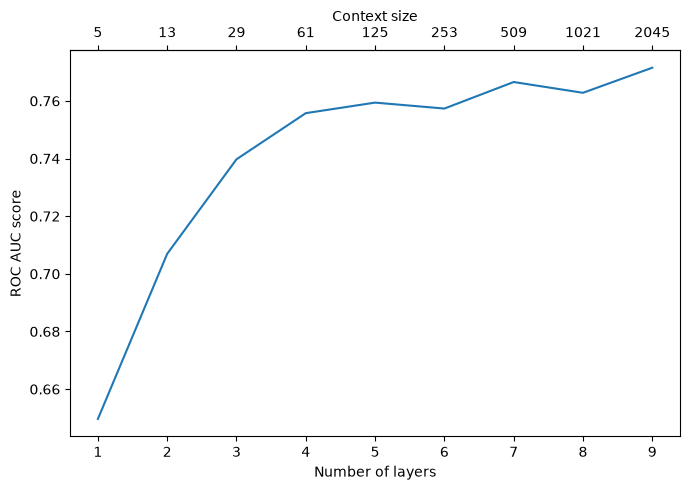

In [19]:
def plot_conv_aucs(n_layer_list, context_size_list, conv_auc_list):
    fig, ax = plt.subplots(figsize = (7, 5))
    
    ax.plot(n_layer_list, conv_auc_list)
    ax.set_xlabel("Number of layers")
    ax.set_ylabel("ROC AUC score")
    
    context_size_axis = ax.secondary_xaxis("top")
    context_size_axis.set_xticks(n_layer_list)
    context_size_axis.set_xticklabels([str(r) for r in context_size_list])
    context_size_axis.set_xlabel("Context size")
    
    
    plt.tight_layout()
    plt.show()

def calculate_context_size(n_layers, kernel = 5):
    res = 1
    for i in range(n_layers):
        res += (2 ** i) * (kernel - 1)
    return res


context_size_list = []

for n_layers in n_layers_list:
    context_size_list.append(calculate_context_size(n_layers))
    

plot_conv_aucs(n_layers_list, context_size_list, conv_auc_list)

Sa $5$ i više slojeva dobijamo sitna poboljšanja, a model postaje veći i sporiji. Zato, odlučujemo se za $4$ kao optimalan broj modela.

Iz ovoga možemo izvesti zaključak da se odluka o uređenosti aminokiselina većinski zasniva na kontekstu širine oko $60$. Dakle, kontekst definitivno ima uticaj, ali ne preveliki kontekst.

In [20]:
best_number_of_layers = 4 

best_index = 0

for i in range(len(n_layers_list)):
    if(n_layers_list[i] == best_number_of_layers):
        best_index = i
        break

conv_model = conv_models[best_index]
best_roc_auc = conv_auc_list[best_index]

print('Best number of layers:', best_number_of_layers)
print('Best ROC AUC score:', best_roc_auc)

Best number of layers: 4
Best ROC AUC score: 0.7557526928370282


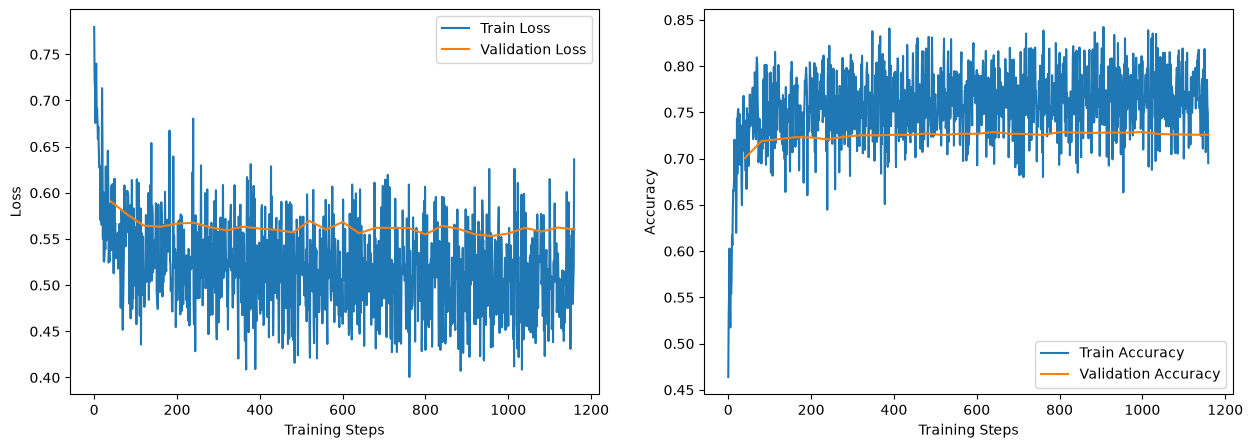

In [21]:
plot_metrics(conv_metrics_dict[best_number_of_layers])

Čuvamo model sa $4$ sloja kao najbolji.

In [22]:
torch.save(conv_model.state_dict(), f"saved_models/conv_model_best.pt")

## Rekurentna neuronska mreža - LSTM

In [23]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # koristimo dvosmerni LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        
        self.linear = nn.Linear(2*hidden_size, 1)
    
    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)

        x = self.linear(x)
        return x

In [24]:
device = get_device()

retrain_lstm = False

lstm_model = LSTMModel(vocab_size=VOCAB_SIZE, embedding_dim=32, hidden_size=64)
lstm_model.to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), weight_decay = 1e-4, lr = 1e-3)

if retrain_lstm == True:
        print('Training LSTM model')
        lstm_metrics = train_model(lstm_model, optimizer, 50, train_loader, val_loader, threshold=0.5)
        
        torch.save(lstm_model.state_dict(), f"saved_models/lstm_model.pt")
        with open(f"saved_models/model_metrics/lstm_model.json", "w") as f:
            json.dump(lstm_metrics, f)
else:
    lstm_model.load_state_dict(torch.load(f"saved_models/lstm_model.pt"))
    lstm_model.eval()
    with open(f"saved_models/model_metrics/lstm_model.json") as f:
        lstm_metrics = json.load(f)

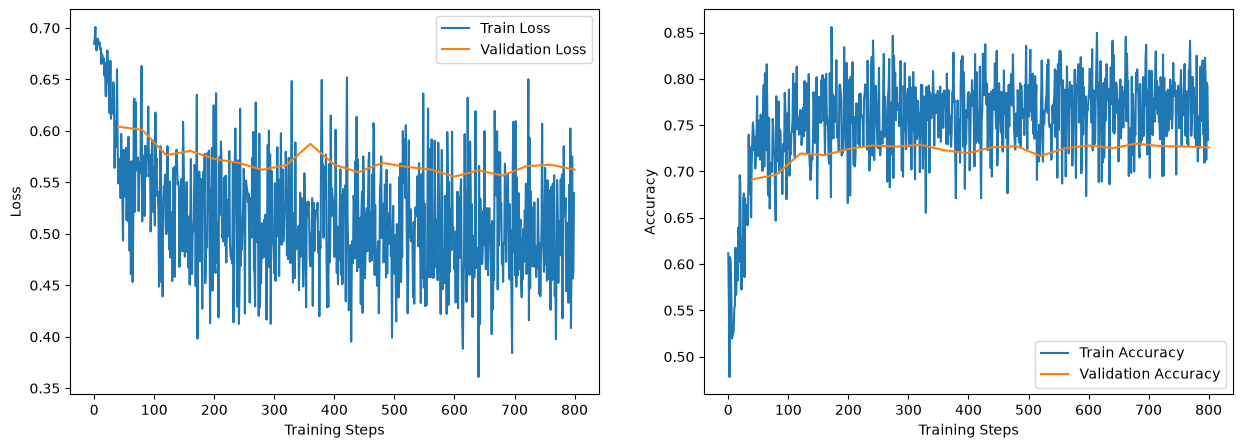

In [25]:
plot_metrics(lstm_metrics)

In [26]:
torch.save(lstm_model.state_dict(), "saved_models/lstm_model.pt")

# Evaluacija

In [27]:
conv_stats = evaluate_model(conv_model, test_loader, threshold = 0.5)

print(conv_stats['confusion_matrix'])
print(conv_stats['classification_report'])
print('Sensitivity:', conv_stats['sensitivity'])
print('Specificity:', conv_stats['specificity'])
print('Accuracy:', conv_stats['accuracy'])
print('ROC AUC score:', conv_stats['roc_auc_score'])

[[134459  25449]
 [ 48692  71535]]
              precision    recall  f1-score   support

           0       0.73      0.84      0.78    159908
           1       0.74      0.59      0.66    120227

    accuracy                           0.74    280135
   macro avg       0.74      0.72      0.72    280135
weighted avg       0.74      0.74      0.73    280135

Sensitivity: 0.5949994593560515
Specificity: 0.8408522400380218
Accuracy: 0.7353383190247559
ROC AUC score: 0.7593737142065368


In [28]:
lstm_stats = evaluate_model(lstm_model, test_loader, threshold = 0.5)

print(lstm_stats['confusion_matrix'])
print(lstm_stats['classification_report'])
print('Sensitivity:', lstm_stats['sensitivity'])
print('Specificity:', lstm_stats['specificity'])
print('Accuracy:', lstm_stats['accuracy'])
print('ROC AUC score:', lstm_stats['roc_auc_score'])

[[133490  26418]
 [ 48230  71997]]
              precision    recall  f1-score   support

           0       0.73      0.83      0.78    159908
           1       0.73      0.60      0.66    120227

    accuracy                           0.73    280135
   macro avg       0.73      0.72      0.72    280135
weighted avg       0.73      0.73      0.73    280135

Sensitivity: 0.5988421901902234
Specificity: 0.8347925056907722
Accuracy: 0.7335284773412819
ROC AUC score: 0.7614315428558825


In [29]:
existing_models = pd.DataFrame([
    ("DisEMBL-465", 0.4191, 0.9503, 0.7414),
    ("DisEMBL-hl", 0.5301, 0.7206, 0.6456),
    ("ESpritzD", 0.4197, 0.9574, 0.7459),
    ("ESpritzN", 0.6862, 0.8081, 0.7966),
    ("ESpritzX", 0.5714, 0.9553, 0.8043),
    ("FoldIndex", 0.6223, 0.7593, 0.7061),
    ("GlobPlot", 0.4073, 0.9100, 0.6952),
    ("IUPredL", 0.6442, 0.9167, 0.8056),
    ("IUPredS", 0.5496, 0.9409, 0.7870),
    ("JRONN", 0.7258, 0.8125, 0.7789),
    ("VSL2b", 0.8067, 0.7750, 0.7875),
], columns=["Model", "Sensitivity", "Specificity", "Accuracy"])

existing_models

,Model,Sensitivity,Specificity,Accuracy
0,DisEMBL-465,0.4191,0.9503,0.7414
1,DisEMBL-hl,0.5301,0.7206,0.6456
2,ESpritzD,0.4197,0.9574,0.7459
3,ESpritzN,0.6862,0.8081,0.7966
4,ESpritzX,0.5714,0.9553,0.8043
5,FoldIndex,0.6223,0.7593,0.7061
6,GlobPlot,0.4073,0.9100,0.6952
7,IUPredL,0.6442,0.9167,0.8056
8,IUPredS,0.5496,0.9409,0.7870
9,JRONN,0.7258,0.8125,0.7789


In [30]:
project_models = pd.DataFrame([
    ("1D Conv. Model", conv_stats['sensitivity'], conv_stats['specificity'], conv_stats['accuracy']),
    ("LSTM Model", lstm_stats['sensitivity'], lstm_stats['specificity'], lstm_stats['accuracy'])
], columns=["Model", "Sensitivity", "Specificity", "Accuracy"])

project_models

,Model,Sensitivity,Specificity,Accuracy
0,1D Conv. Model,0.594999,0.840852,0.735338
1,LSTM Model,0.598842,0.834793,0.733528


In [31]:
def plot_roc_curve(model_stat_list, existing_models):
    plt.figure(figsize=(8,8))
    
    for model_stats in model_stat_list:
        fpr, tpr, _ = roc_curve(model_stats['labels'], model_stats['probs'])
        auc = roc_auc_score(model_stats['labels'], model_stats['probs'])
        
        plt.plot(fpr, tpr, label = f"{model_stats['name']} -- AUC = {auc:.4}")
    
    plt.plot([0, 1], [0, 1], ls="--", color="black")
    
    
    if(len(existing_models) > 0):
        xs = 1 - existing_models["Specificity"].values
        ys = existing_models["Sensitivity"].values
        plt.scatter(xs, ys, color='darkred', label="Individual predictors (paper)")

    
    for _, row in existing_models.iterrows():
        plt.annotate(row["Model"], (1 - row["Specificity"], row["Sensitivity"]), \
                    textcoords="offset points", xytext=(6, -2))

    
    
    plt.grid(True, alpha=0.5)
    
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.legend()
    plt.tight_layout()
    
    plt.savefig('images/roc_curve.png', dpi=300, bbox_inches='tight')
    
    plt.show()

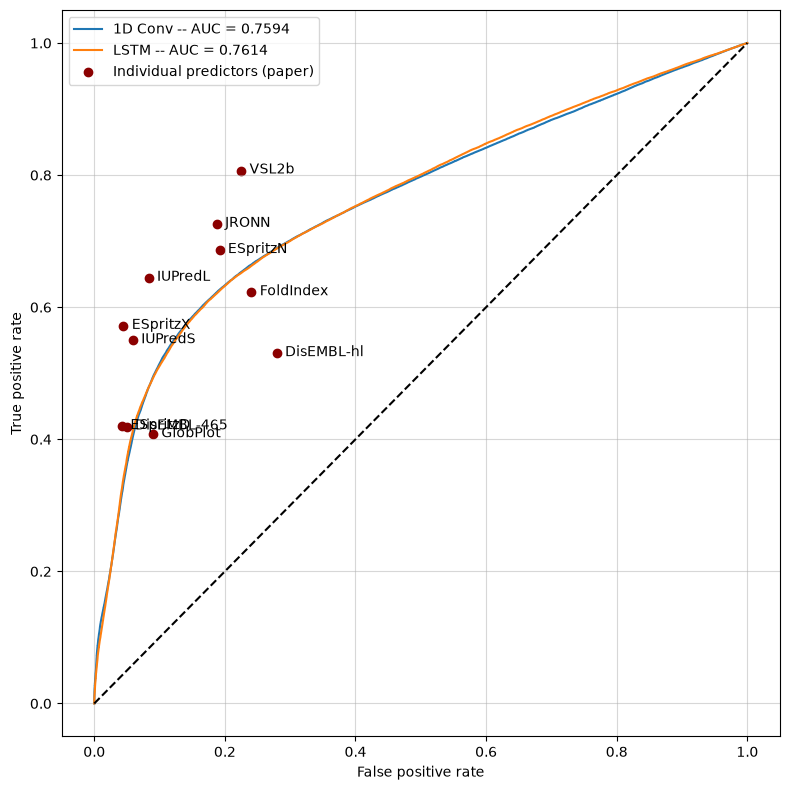

In [32]:
conv_stats['name'] = "1D Conv"
lstm_stats['name'] = "LSTM"

plot_roc_curve([conv_stats, lstm_stats], existing_models)

Vidimo da su oba modela gotovo ista.

## Vizualizacija na primeru

/tmp/ipykernel_15016/318998562.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor([seq])


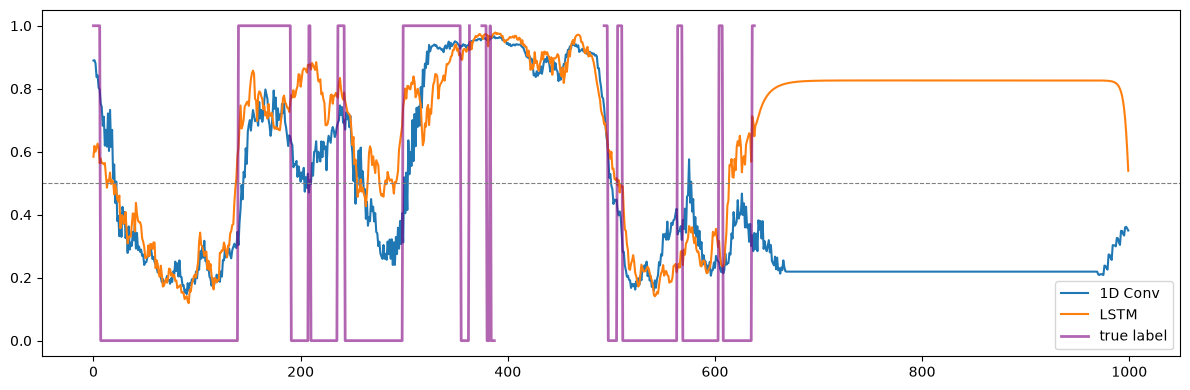

In [33]:
def plot_protein_predictions(models, seq, labels):
    
    plt.figure(figsize=(12, 4))
    
    for model, model_label in models:
        model.eval()
        with torch.no_grad():
            x = torch.tensor([seq])
            x = x.to(get_device())
            probs = torch.sigmoid(model(x)).cpu().numpy().squeeze()

            plt.plot(probs, label=model_label)
            
    truth = np.array([v if v > -1 else np.nan for v in labels])
    
    plt.plot(truth, label="true label", linewidth=2, alpha=0.6, color="purple")
    plt.axhline(0.5, ls="--", c="gray", lw=0.8)

    plt.legend()
    plt.tight_layout()
    plt.show()

    
idx = np.random.randint(0, len(seq_test))
sample_test_protein_seq = seq_test[idx]
sample_test_protein_labels = labels_test[idx]
plot_protein_predictions([(conv_model, "1D Conv"), (lstm_model, "LSTM")], sample_test_protein_seq, sample_test_protein_labels)

Vizualizacijom raznih primera može se doći do zaključka da su naši modeli previše rigidni, tj. da ne reaguju dovoljno brzo na uređene/neuređene oblasti male dužine. To se u konvolutivnoj neuronskoj mreži može rešiti npr. smanjenjem dilatacije, mada rezulati izbora hiperparametra pokazuju da se gledanjem širokog konteksta zaista postiže bolji rezultat. Dakle, iako ne reaguju na male oblasti, modeli imaju sposobnost da ostaju konzistentni na velikoj, pa time zaista predviđaju velike povezane oblasti, a ne samo nasumične niske nula i jedinica.